# Research Question: “How do heart rate and blood pressure interactions change over time during surgery?”



# Data Acquisition and Preparation
- Read the instructions provided to access VitalDB and select one of the datasets.
- Identify at least two vital signals (tracks) from the chosen dataset for univariate and multivariate signal analysis. Choose signals that are clinical relevant to analyse together. 
- Thoroughly inspect and clean the dataset, addressing datatype formats, missing values, outliers, and other anomalies.
- Using the insights from the previous steps, construct a parser module (python script that loads, cleans and reformat the data into a required format).
  
**Deliverable: Parser module**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scripts.parser import load_data, data_info, preprocess_vital_signs
from scripts.visualization import static_plot_vitals, create_dynamic_time_series_plot
from scripts.analysis import analyze_vital_signs
from datetime import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

INFO:scripts.parser:Module 'scripts.parser' imported successfully!
INFO:scripts.visualization:Module 'scripts.visualization' imported successfully!
INFO:scripts.analysis:Module 'scripts.analysis' imported successfully!


In [3]:
# setting variables for the vital signs
SYS = 'Solar8000/ART_SBP'
DIA = 'Solar8000/ART_DBP'
HRT = 'Solar8000/HR'

In [4]:
# Load Data: Takes a few seconds as the data size is relatively large
vitals = load_data('vitaldb')

INFO:scripts.parser:Successfully loaded data with shape: (29582, 4)


In [5]:
data_info(vitals)

Data Shape: (29582, 4)
Duplicate Indices: 0
Duplicate Rows: 19260
Total NaN Values: 2793
NaN Percentage: 3.15%

NaN counts by column:
  Solar8000/ART_SBP: 1255
  Solar8000/ART_DBP: 1234
  Solar8000/HR: 304

<class 'pandas.core.frame.DataFrame'>
Index: 29582 entries, 00:00:00 to 16:26:02
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Solar8000/ART_SBP  28327 non-null  float64
 1   Solar8000/ART_DBP  28348 non-null  float64
 2   Solar8000/HR       29278 non-null  float64
 3   EVENT              4 non-null      object 
dtypes: float64(3), object(1)
memory usage: 2.1+ MB


What we can see from the data info and the dataframe itself is:

- The data is recorded every two seconds.

- The first and last few rows are empty which are after the EVENT = case started, and before EVENT = Case finished. This can indicate the connecting / disconnecting the monitoring devices.

- Number of duplicate rows: 19260 and Number of duplicate indices: 0 shows that there are no indices (timestamps) repeating due to error but the values of the rows happen to be identical for multiple rows. Given the nature and range of the Blood Pressure and Heart Rate, I don't think it's a cause of concern, as they may remain the same if the patient is stable. So I won't do anything about them.

- There are also nan values during the surgery which we will probably need to impute.

- In the next step we visualize the data to get a better overview of data distribution, and take further steps in preprocessing.


# Visualization
- Visualize the vital signal information using appropriate visualization techniques.
  
**Deliverable: visualization module**

INFO:scripts.visualization:Static plot created for Solar8000/ART_DBP


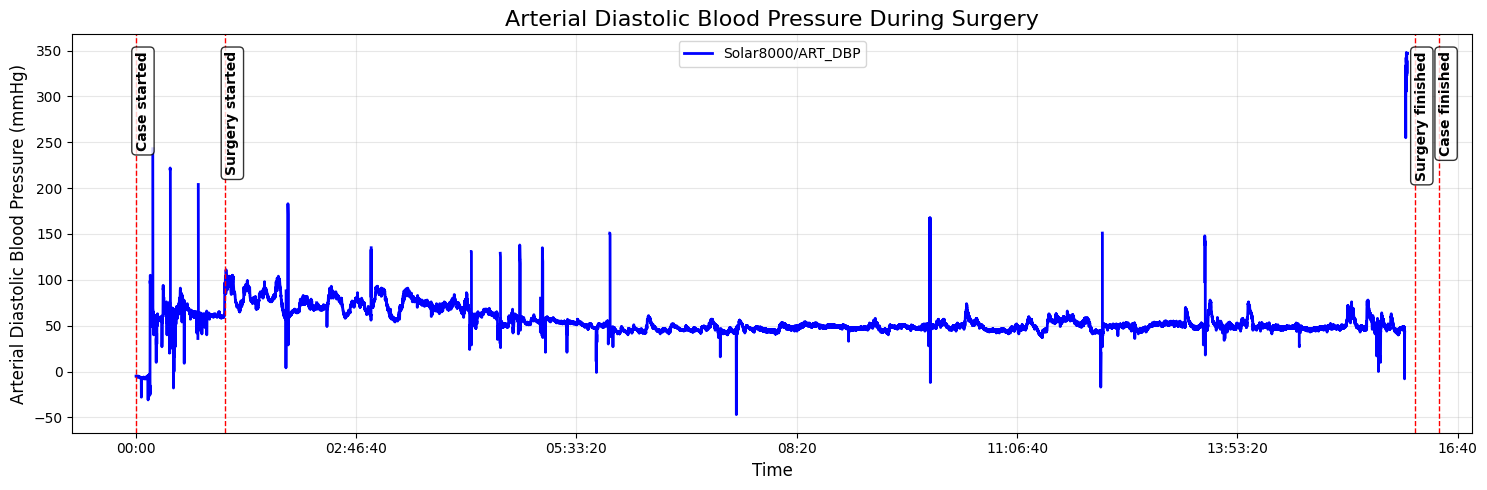

INFO:scripts.visualization:Static plot created for Solar8000/ART_SBP


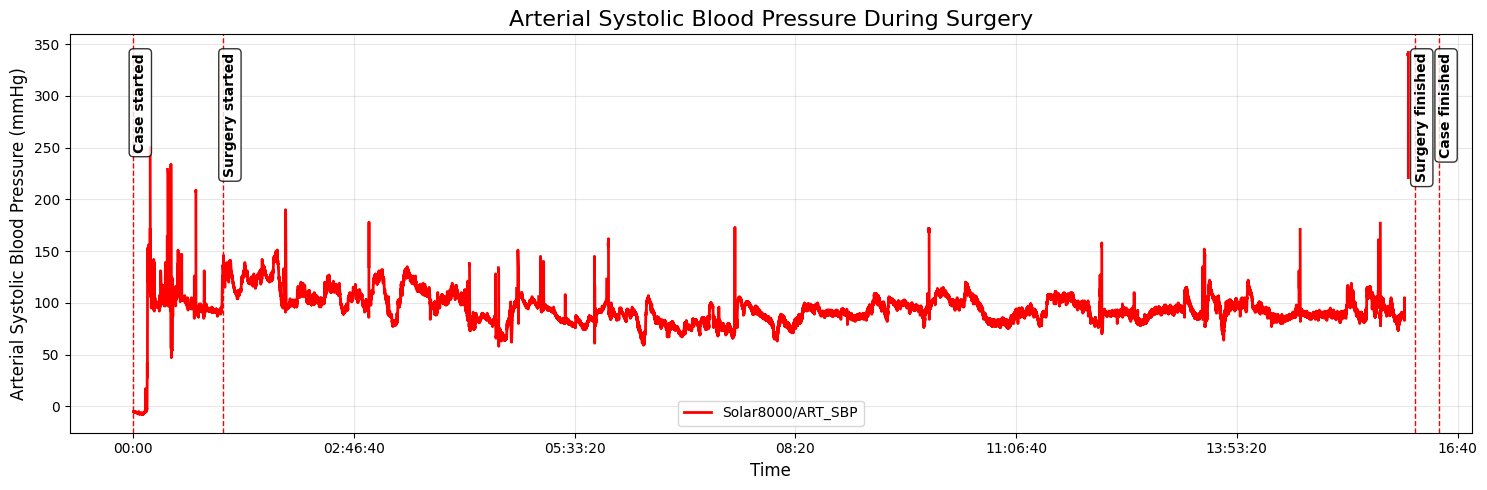

INFO:scripts.visualization:Static plot created for Solar8000/HR


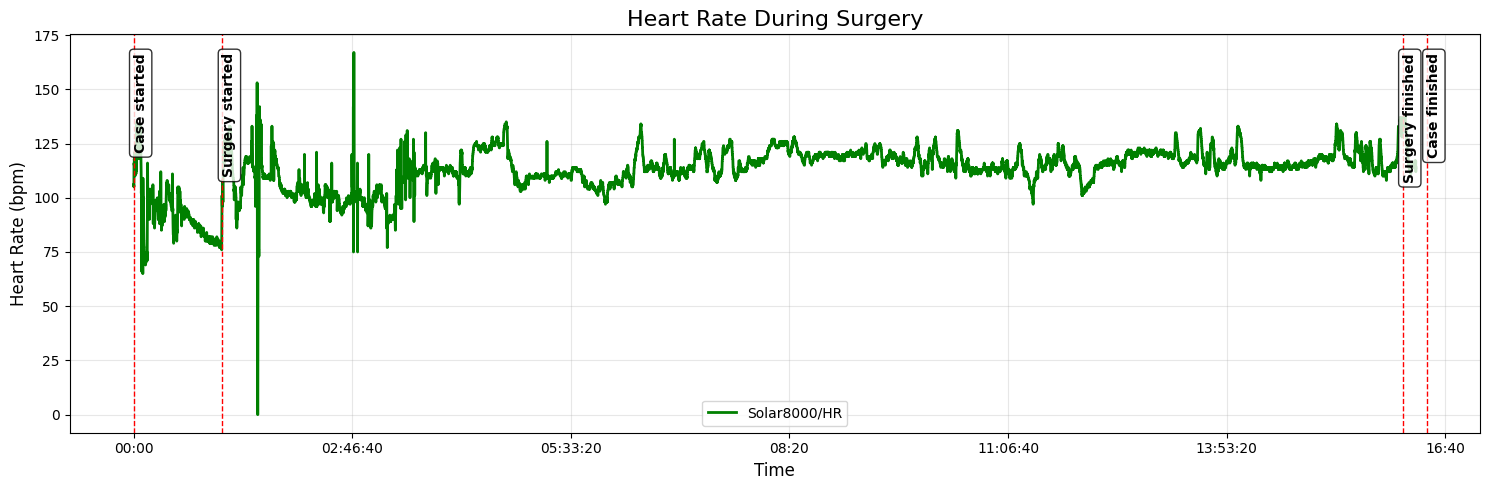

In [6]:
static_plot_vitals(vitals)

In [7]:
# create_dynamic_time_series_plot(vitals,SYS)
# create_dynamic_time_series_plot(vitals, DIA)
# create_dynamic_time_series_plot(vitals, HRT)

By inspecting the static and dynamic plots we can see:
- There are out of range values.  
- There are null values that require special handling.  

So more advanced preprocessing is needed.

In [8]:
# We care about the data during the surgery as the connecting/disconnecting devices part are not relevant for our analysis; they are artifacts.
start = vitals[vitals['EVENT']== 'Surgery started'].index[0]
end = vitals[vitals['EVENT']== 'Surgery finished'].index[0]

I decided **not** to exclude outliers that are still within the reasonable range. Because vital signs' significant peaks or drops are possible during the surgery, for example heart rate drops, particularly during laparoscopy or with specific anesthetic agents, is possible. Vigilance for bradycardia as an early warning sign (even in healthy patients) and rapid intervention are critical to prevent progression to cardiac arrest.[source](https://www.anaesthesiacollective.com/bradycardias-during-anaesthesia/)

In [9]:
vitals_c = vitals.copy()
vitals_no_event = vitals_c.loc[start:end]
vitals_no_event.loc[:, HRT], hr_nan = preprocess_vital_signs(vitals_no_event[HRT], 'hr')
vitals_no_event.loc[:, DIA], dia_nan = preprocess_vital_signs(vitals_no_event[DIA], 'dbp')
vitals_no_event.loc[:,SYS], sys_nan = preprocess_vital_signs(vitals_no_event[SYS], 'sbp')

INFO:scripts.parser:Marked 8 values as outliers
INFO:scripts.parser:Initial NaN count: 53 (0.20%)
INFO:scripts.parser:After linear interpolation: 0 NaNs remaining
INFO:scripts.parser:Preprocessing completed successfully
INFO:scripts.parser:Marked 97 values as outliers


INFO:scripts.parser:Initial NaN count: 704 (2.61%)
INFO:scripts.parser:After linear interpolation: 320 NaNs remaining
INFO:scripts.parser:After forward/backward fill: 235 NaNs remaining
INFO:scripts.parser:After EWMA fill: 0 NaNs remaining
INFO:scripts.parser:Preprocessing completed successfully
INFO:scripts.parser:Marked 3 values as outliers
INFO:scripts.parser:Initial NaN count: 631 (2.34%)
INFO:scripts.parser:After linear interpolation: 259 NaNs remaining
INFO:scripts.parser:After forward/backward fill: 165 NaNs remaining
INFO:scripts.parser:After EWMA fill: 0 NaNs remaining
INFO:scripts.parser:Preprocessing completed successfully


Below we can see the consecutive gaps, their sample counts, start, end and duration.

In [10]:
hr_nan = hr_nan.sort_values(by ='count', ascending=False)
hr_nan.head(10)

,count,start_time,end_time,duration
1,10,0 days 02:16:42,0 days 02:17:00,0 days 00:00:19
3,10,0 days 07:16:50,0 days 07:17:08,0 days 00:00:19
15,9,0 days 12:17:00,0 days 12:17:16,0 days 00:00:17
0,8,0 days 01:34:26,0 days 01:34:40,0 days 00:00:15
2,1,0 days 06:17:54,0 days 06:17:54,0 days 00:00:01
4,1,0 days 07:56:24,0 days 07:56:24,0 days 00:00:01
6,1,0 days 07:56:34,0 days 07:56:34,0 days 00:00:01
5,1,0 days 07:56:30,0 days 07:56:30,0 days 00:00:01
8,1,0 days 07:56:48,0 days 07:56:48,0 days 00:00:01
9,1,0 days 07:56:56,0 days 07:56:56,0 days 00:00:01


In [11]:
dia_nan= dia_nan.sort_values(by ='count', ascending=False)
dia_nan.head(10)

,count,start_time,end_time,duration
59,229,0 days 16:00:04,0 days 16:07:40,0 days 00:07:37
43,40,0 days 12:09:56,0 days 12:11:14,0 days 00:01:19
1,36,0 days 01:53:38,0 days 01:54:48,0 days 00:01:11
13,33,0 days 05:06:08,0 days 05:07:12,0 days 00:01:05
9,32,0 days 04:34:18,0 days 04:35:20,0 days 00:01:03
56,27,0 days 15:40:20,0 days 15:41:12,0 days 00:00:53
4,27,0 days 02:58:02,0 days 02:58:54,0 days 00:00:53
48,26,0 days 13:27:48,0 days 13:28:38,0 days 00:00:51
12,25,0 days 04:49:28,0 days 04:50:16,0 days 00:00:49
19,25,0 days 05:57:30,0 days 05:58:18,0 days 00:00:49


In [12]:
sys_nan = sys_nan.sort_values(by ='count', ascending=False)
sys_nan.head(10)

,count,start_time,end_time,duration
39,145,0 days 16:02:52,0 days 16:07:40,0 days 00:04:49
34,54,0 days 16:00:08,0 days 16:01:54,0 days 00:01:47
0,36,0 days 01:53:38,0 days 01:54:48,0 days 00:01:11
8,33,0 days 05:06:08,0 days 05:07:12,0 days 00:01:05
5,32,0 days 04:34:18,0 days 04:35:20,0 days 00:01:03
25,30,0 days 12:10:14,0 days 12:11:12,0 days 00:00:59
2,27,0 days 02:58:02,0 days 02:58:54,0 days 00:00:53
31,27,0 days 15:40:20,0 days 15:41:12,0 days 00:00:53
27,26,0 days 13:27:48,0 days 13:28:38,0 days 00:00:51
3,25,0 days 04:12:38,0 days 04:13:26,0 days 00:00:49


We can see that most consecutive nan values are related to the end of the surgery, probably when they were unhooking the devices.
As the total percentage of the missing values is under 3% for each signal, the methods we have used for imputation, although crude, can be considered acceptable.

I decided not to use detrending, as I think it's important to notice the long-term changes in vital signs during the surgery. They are essential for understanding the patient’s physiological state, detecting complications early, and guiding intraoperative and postoperative care.

Although the option of smoothing is implemented, I decided not to use it as I want to take into account all the fluctuations for later analysis, and the sampling time is 2 seconds, so the samples are not very close to each other in time. However, this option can be used for seeing trends more clearly.

In [13]:
vitals_no_event

,Solar8000/ART_SBP,Solar8000/ART_DBP,Solar8000/HR,EVENT
01:07:40,136.000000,104.000000,104.0,Surgery started
01:07:42,134.000000,91.000000,106.0,NaN
01:07:44,134.000000,97.000000,106.0,NaN
01:07:46,134.000000,97.000000,107.0,NaN
01:07:48,137.000000,97.000000,107.0,NaN
...,...,...,...,...
16:07:32,183.459294,43.704453,135.0,NaN
16:07:34,183.459294,43.704453,135.0,NaN
16:07:36,183.459294,43.704453,137.0,NaN
16:07:38,183.459294,43.704453,136.0,NaN


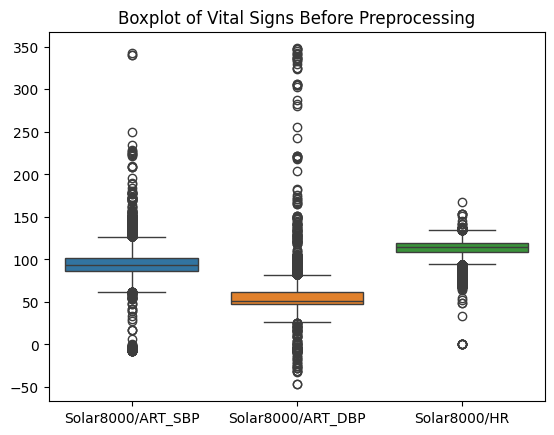

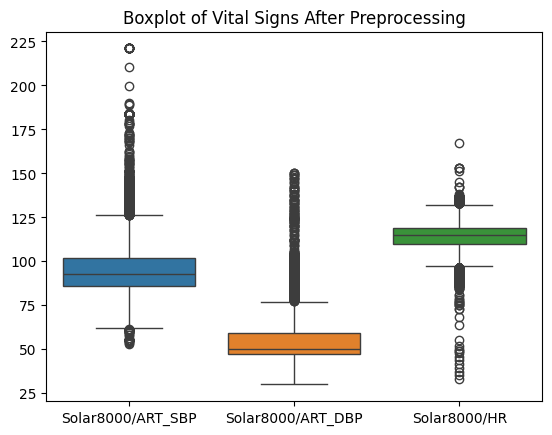

In [14]:
sns.boxplot(vitals).set_title('Boxplot of Vital Signs Before Preprocessing')
plt.show()

sns.boxplot(vitals_no_event).set_title('Boxplot of Vital Signs After Preprocessing')
plt.show()


In [15]:
vitals_no_event.describe()

,Solar8000/ART_SBP,Solar8000/ART_DBP,Solar8000/HR
count,27001.000000,27001.000000,27001.000000
mean,95.451441,55.434722,114.219529
std,15.720384,13.063381,8.001323
min,53.000000,30.000000,33.000000
25%,86.000000,47.000000,110.000000
50%,93.000000,50.000000,115.000000
75%,102.000000,59.000000,119.000000
max,221.000000,150.000000,167.000000


In [16]:
vitals.describe()

,Solar8000/ART_SBP,Solar8000/ART_DBP,Solar8000/HR
count,28327.000000,28348.000000,29278.000000
mean,94.070886,55.521765,112.751998
std,17.777320,17.278702,10.247286
min,-8.000000,-47.000000,0.000000
25%,86.000000,47.000000,109.000000
50%,93.000000,51.000000,114.000000
75%,102.000000,61.000000,119.000000
max,342.000000,348.000000,167.000000


INFO:scripts.visualization:Static plot created for Solar8000/ART_DBP


BEFORE PRE-PROCESSING



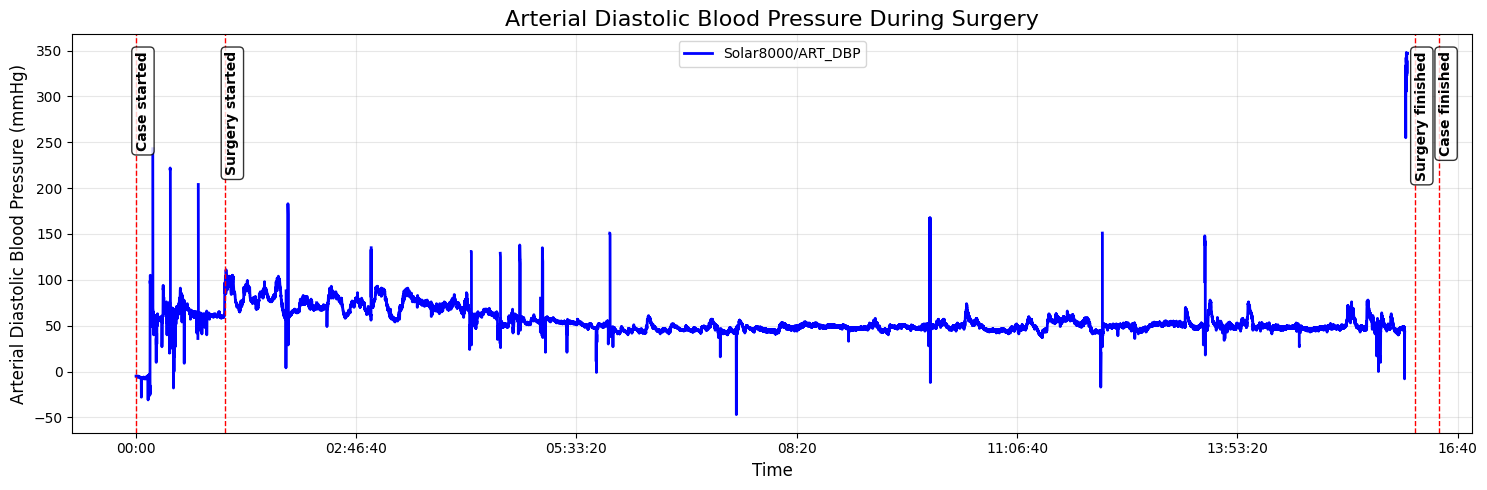

INFO:scripts.visualization:Static plot created for Solar8000/ART_SBP


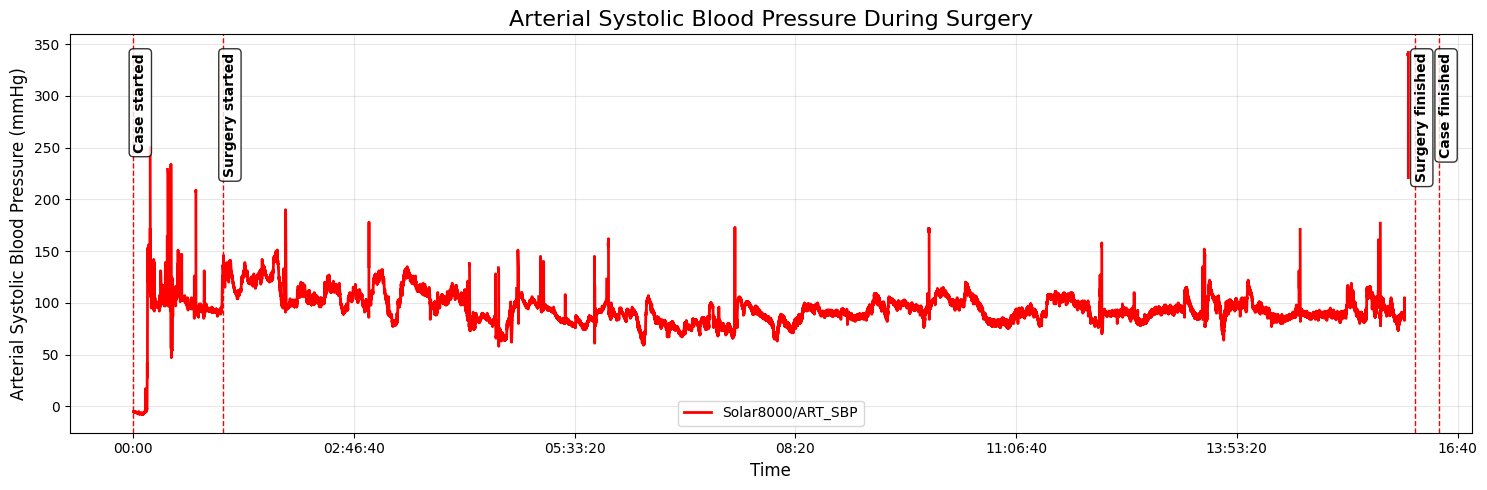

INFO:scripts.visualization:Static plot created for Solar8000/HR


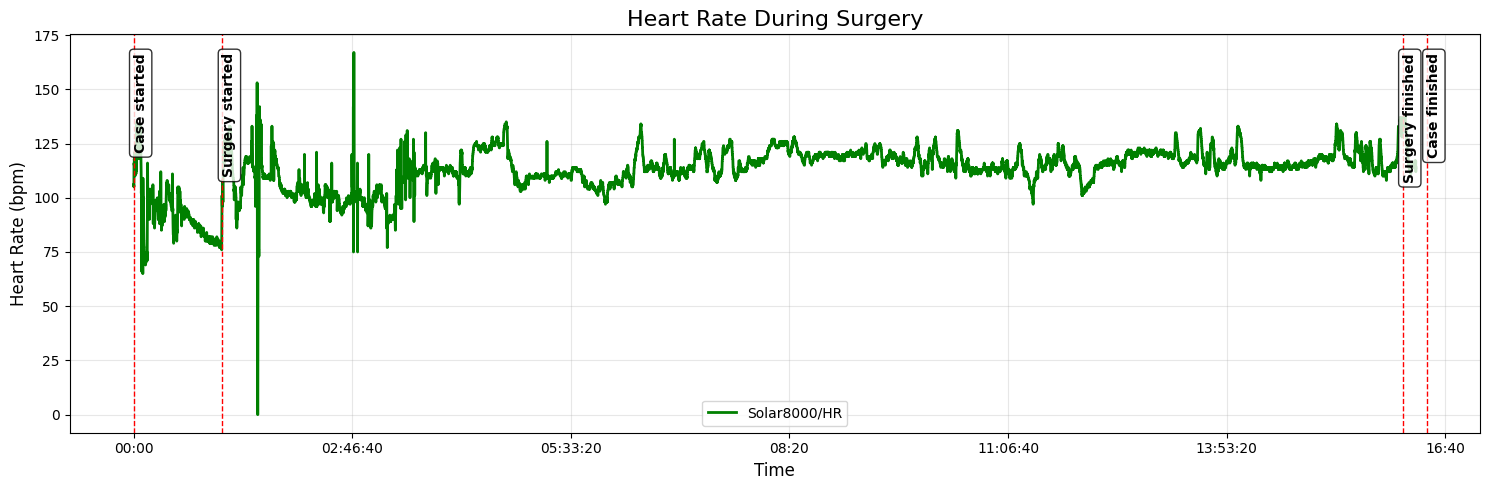

INFO:scripts.visualization:Static plot created for Solar8000/ART_DBP




AFTER PRE-PROCESSING




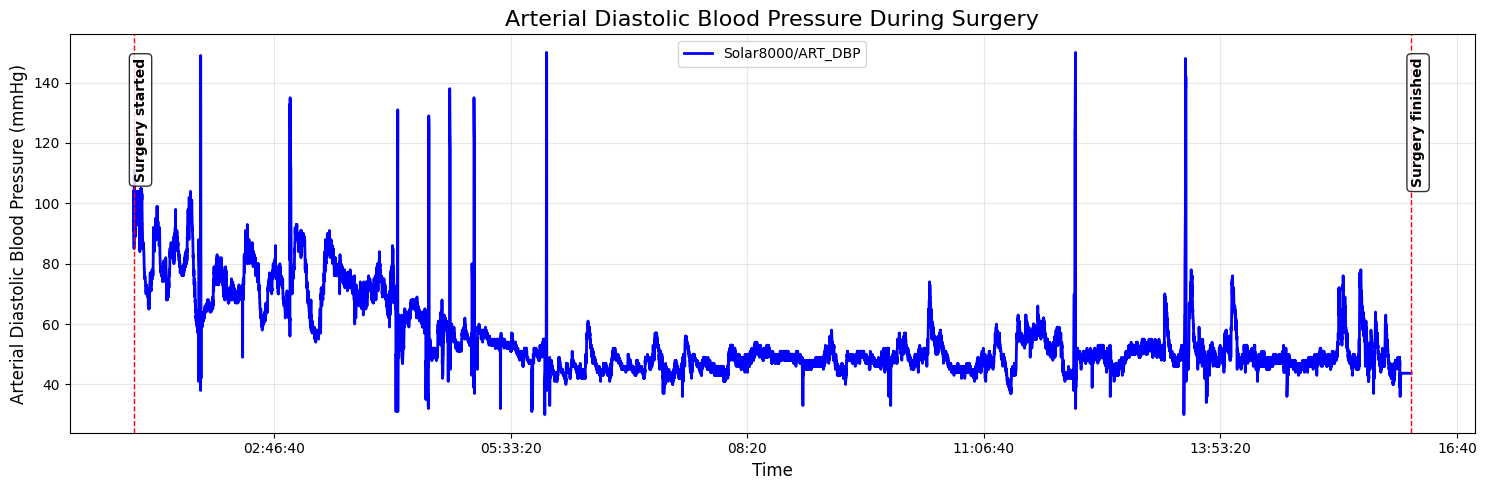

INFO:scripts.visualization:Static plot created for Solar8000/ART_SBP


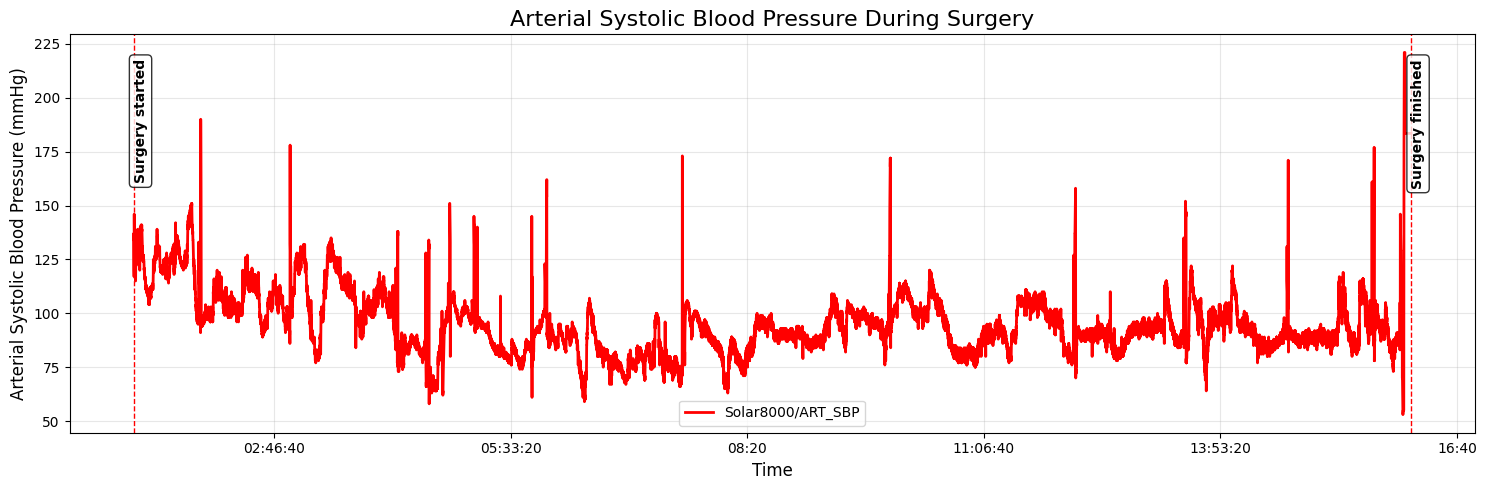

INFO:scripts.visualization:Static plot created for Solar8000/HR


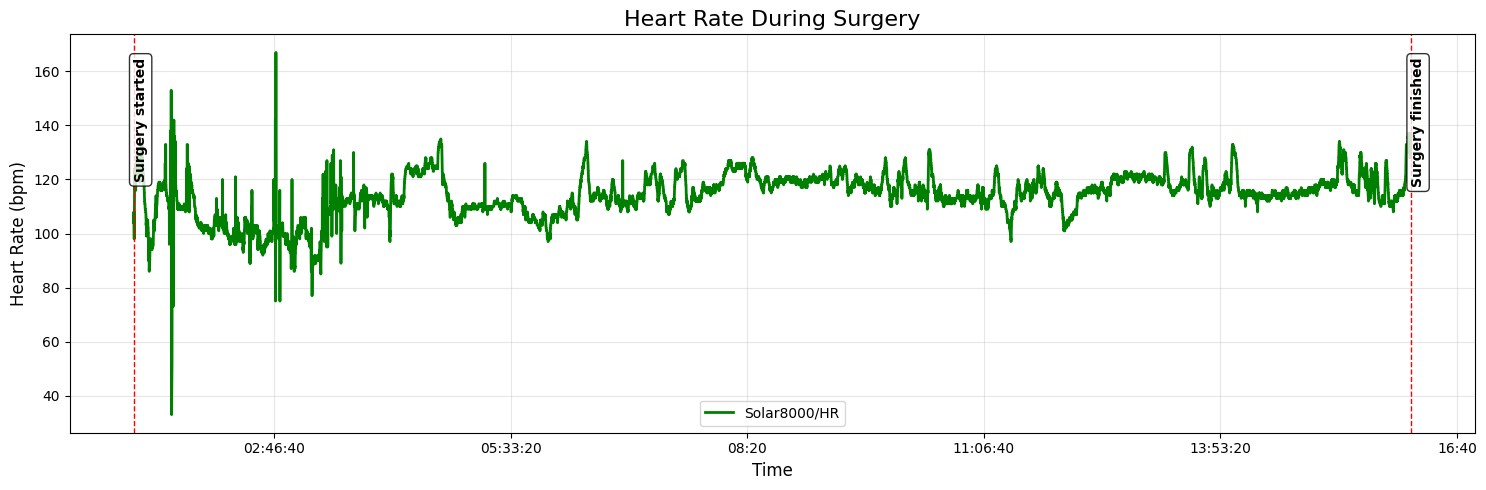

In [17]:
print("BEFORE PRE-PROCESSING\n")
static_plot_vitals(vitals)
print("\n\nAFTER PRE-PROCESSING\n\n")
static_plot_vitals(vitals_no_event)

We can see in the boxplot and statistical description tables, that the preprocessing has successfully:
- Applied sensible ranges for the vital signs.
- Imputed nan values, depending on the duration of consecutive nan values.

## Upper/lower limit values:
---

| Signal | Lower Bound | Upper Bound | Source                     |
|--------|-------------|-------------|----------------------------|
| HR     | 30 bpm      | 180 bpm     | AHA Guidelines, PhysioNet  |
| SBP    | 50 mmHg     | 250 mmHg    | AAMI Standards, ICU datasets |
| DBP    | 30 mmHg     | 150 mmHg    | AAMI, PhysioNet            |



## Solar8000 Data Loss and Spikes:

---

### **Normal vs. Abnormal Durations**

| **Parameter** | **Normal Artifact/Spike Duration** | **Abnormal Duration** | **Causes** |
| :-- | :-- | :-- | :-- |
| **Heart Rate (HR)** | <10 seconds[^5] | >30 seconds[^5] | - **Normal**: Motion artifacts, lead reseating[^4]<br>- **Abnormal**: Arrhythmia events (e.g., sustained VT), TRAM module failure[^3] |
| **Systolic ABP** | <15 seconds[^5] | >60 seconds[^5] | - **Normal**: Catheter flushing[5]<br>- **Abnormal**: Pressure sensor faults, network IP conflicts causing data loss[^3] |
| **Diastolic ABP** | <15 seconds[^3] | >60 seconds[^3] | - **Normal**: Damped waveforms during patient movement[^3]<br>- **Abnormal**: Disconnected transducer, air bubbles in line[^3] |

---
<div>⁂</div>

[^1]: https://pubmed.ncbi.nlm.nih.gov/35957328/

[^2]: https://sites.nd.edu/gonzalo-martinez/files/2020/03/HeartImp_SDM20201.pdf

[^3]: https://avobus.com/pdf/GE/GEHC-Solar8000M-Service.pdf

[^4]: https://support.mindwaretech.com/2016/07/all-about-ecg-part-4-basic-artifact-correction/

[^5]: https://www.piobio.com/wp-content/uploads/2021/06/GE_Solar8000M_MaintenanceCheckout-copy.pdf

**Conclusion**:

- **<15 to 30-second gaps**: Typically benign technical artifacts.
- **>60-second gaps**: Likely indicate critical failures requiring intervention.







In [18]:
# create_dynamic_time_series_plot(vitals_no_event, HRT)
# create_dynamic_time_series_plot(vitals_no_event, SYS)
# create_dynamic_time_series_plot(vitals_no_event, DIA)

# Feature Extraction and Analysis
- Explore the dataset to extract relevant features from the vital sign signals, enhancing the depth of data understanding.
- Using the insights from the previous steps, design and implement an analyzer module capable of summarizing signal data and derived features over specified time frames.

**Deliverable: Analyzer module**

### **Metrics Explanation**

#### **Skewness**

- **Definition**: Skewness measures the symmetry of a data distribution. It indicates whether the data is skewed toward the left or right tail.
- **Types**:
    - **Negative Skewness**: Distribution stretches more toward the left tail (larger values dominate).
    - **Positive Skewness**: Distribution stretches more toward the right tail (smaller values dominate).
    - **Zero Skewness**: Symmetric distribution (e.g., normal distribution).
- **Thresholds**:
    - Values between **-1 and +1** are considered excellent.
    - Values between **-2 and +2** are generally acceptable.
    - Values beyond these ranges indicate substantial non-normality.
- **Applications**:
    - Used in exploratory data analysis to assess data symmetry.
    - Influences preprocessing decisions, such as outlier removal or feature scaling.

---

#### **Kurtosis**

- **Definition**: Kurtosis measures the "tailedness" or peakedness of a distribution compared to a normal distribution.
- **Types**:
    - **Mesokurtic (kurtosis = 3)**: Normal distribution with moderate tails and peak.
    - **Leptokurtic (kurtosis > 3)**: Sharp peak and heavy tails; higher likelihood of extreme values.
    - **Platykurtic (kurtosis < 3)**: Flat peak and light tails; fewer extreme values.
- **Excess Kurtosis**:
    - Defined as \$ kurtosis - 3 \$, treating kurtosis of a normal distribution as zero for interpretability.
- **Thresholds**:
    - Excess kurtosis between **-2 and +2** is generally acceptable.
- **Applications**:
    - Used to identify distributions with extreme values or outliers.
    - Helps in risk assessment and anomaly detection in fields like finance and healthcare.

---
#### **Coefficient of Variation (CV)**

- **Definition**:
$$
CV = \frac{\text{Standard Deviation}}{\text{Mean}} \times 100\%
$$
A **unitless measure** of relative variability.
- **Surgical Applications**:

    - **BP Stability**: 
        - Low BP CV:  
            Stable BP: Consistent readings with minimal fluctuations.
        - High BP CV:  
            Excessive fluctuations in BP over time

    - **HR Stability**: 
        - Low HR CV: Expected under stable anesthesia (autonomic suppression). Concerning if it's sudden (e.g., bradycardia with hypotension).
        
        - High HR CV:  
            Stress Response: May indicate inadequate analgesia.

---

### **SBP - DBP (Pulse Pressure)**

#### **Definition**

*"The difference between systolic and diastolic blood pressures"*

- **Source**: StatPearls (NCBI Bookshelf) defines pulse pressure as SBP – DBP[^1][^7].


#### **Normal Range**

*"Typically 30–50 mmHg"*

- **Source**: Normal PP is ~40 mmHg (120/80 mmHg)[^2][^5][^7]. Studies report mean PP as 41.8–45.6 mmHg in healthy adults[^3][^4].


#### **Critical Thresholds**

- **<25 mmHg**:
    - **Hypovolemia**: PP <25% of SBP indicates narrowed PP (StatPearls)[^7].
    - **Low Stroke Volume**: PP ≈ SV/Arterial Compliance (StatPearls)[^1][^7].
- **>60 mmHg**:
    - **Arterial Stiffness**: PP ≥60 mmHg linked to cardiovascular risk (ESC/ESH Guidelines)[^9][^5].
    - **Clinical Threshold**: >65 mmHg predicts mortality (PubMed 11368460)[^4].


#### **Clinical Significance**

- **Arterial Compliance**: PP reflects SV and arterial stiffness (StatPearls)[^7][^5].
- **Surgical Guidance**: PP <25 mmHg suggests hypovolemia (StatPearls)[^1]; PP >60 mmHg requires intervention[^9].

---

### **HR × SBP (Rate-Pressure Product, RPP)**

#### **Definition**

*"Product of HR and SBP"*

- **Source**: RPP = HR × SBP (PubMed 22301391)[^8].


#### **Normal Range During Surgery**

*"12,000–20,000 mmHg·bpm"*

- **Source**:
    - **Stable Anesthesia**: RPP 12,000–20,000 mmHg·bpm (PMC8029839)[^5].
    - **Surgical Stress**: RPP >20,000 during femoral implantation (PMC2505136)[^6].


#### **Critical Thresholds**

- **RPP <12,000**: Anesthesia: Lower RPP (8k–12k) = expected stability.
- **RPP >12,000**:
    - **Ischemia Risk**: Surgery: Moderate RPP (12k–20k) = normal stress response. Elevated RPP correlates with myocardial demand (PubMed 22301391)[^8].
- **RPP >20,000**:
    - **Surgical Stress**: Critical Threshold: RPP >20,000 universally indicates high risk[^6][^5]. Matches cardiovascular strain during intubation/incision (PMC2505136)[^6].


#### **Clinical Significance**

- **Myocardial Demand**: RPP predicts oxygen consumption (PubMed 22301391)[^8].
- **Intraoperative Monitoring**: RPP >20,000 indicates hemodynamic stress (PMC2505136)[^6].

For surgical thresholds, institutional protocols often adapt these general principles (e.g., RPP >20,000 during high-stress steps)[^6][^8].

---

### **Summary Table**

| Parameter | Statement | Source |
| :-- | :-- | :-- |
| **PP <25 mmHg** | Hypovolemia marker | StatPearls[^1] |
| **PP >60 mmHg** | Arterial stiffness | PubMed 11368460[^4] |
| **RPP >12,000** | Ischemia risk | PubMed 22301391[^8] |
| **RPP >20,000** | Surgical stress | PMC2505136[^6] |

**Note**: PP thresholds vary slightly by study (e.g., >65 mmHg in PubMed 11368460[^4] vs. ≥60 mmHg in ESC guidelines[^9]). RPP thresholds are procedure-specific[^6][^8].

<div>⁂</div>

[^1]: https://www.ncbi.nlm.nih.gov/books/NBK482408/

[^2]: https://pubmed.ncbi.nlm.nih.gov/3611771/

[^3]: https://pmc.ncbi.nlm.nih.gov/articles/PMC9760735/

[^4]: https://pubmed.ncbi.nlm.nih.gov/11368460/

[^5]: https://pmc.ncbi.nlm.nih.gov/articles/PMC8029839/

[^6]: https://pmc.ncbi.nlm.nih.gov/articles/PMC2505136/

[^7]: https://pubmed.ncbi.nlm.nih.gov/29494015/

[^8]: https://pubmed.ncbi.nlm.nih.gov/22301391/

[^9]: https://pmc.ncbi.nlm.nih.gov/articles/PMC8686555/

[^10]: https://pubmed.ncbi.nlm.nih.gov/7552876/







### Example of Signal Analysis

In [19]:
# The returned dataframes are color coded, but github does not support it. The picture is included in the report.
# The color coding is applied column-wise.
df_hr, df_sys, df_dia, df_cross = analyze_vital_signs(vitals_no_event,start_time='1:00:00', end_time='2:00:00')

INFO:scripts.analysis:Successfully processed 6 windows


In [20]:
df_hr

,window_start,window_end,hr_mean,hr_median,hr_min,hr_max,hr_std,hr_var,hr_range,hr_iqr,hr_skew,hr_kurtosis,hr_p25,hr_p75,hr_cv
0,01:00:00,01:10:00,118.15,121.00,98.00,129.00,8.35,69.68,31.00,9.00,-0.91,-0.28,116.00,125.00,0.07
1,01:10:00,01:20:00,113.77,118.00,86.00,133.00,13.43,180.31,47.00,23.00,-0.29,-1.27,103.00,126.00,0.12
2,01:20:00,01:30:00,111.16,116.00,94.00,126.00,8.40,70.60,32.00,13.00,-0.85,-0.70,105.00,118.00,0.08
3,01:30:00,01:40:00,110.87,112.00,33.00,153.00,17.60,309.85,120.00,6.00,-2.29,7.82,110.00,116.00,0.16
4,01:40:00,01:50:00,113.32,110.00,108.00,133.00,4.92,24.18,25.00,8.00,0.97,0.02,109.00,117.00,0.04
5,01:50:00,02:00:00,103.87,103.00,100.00,114.00,3.12,9.76,14.00,2.00,1.68,2.23,102.00,104.00,0.03


In [21]:
df_sys

,window_start,window_end,sbp_mean,sbp_median,sbp_min,sbp_max,sbp_std,sbp_var,sbp_range,sbp_iqr,sbp_skew,sbp_kurtosis,sbp_p25,sbp_p75,sbp_cv
0,01:00:00,01:10:00,127.49,127.00,115.00,146.00,6.84,46.80,31.00,10.00,0.43,-0.16,123.00,133.00,0.05
1,01:10:00,01:20:00,121.40,121.00,104.00,141.00,11.68,136.42,37.00,22.00,0.17,-1.43,110.00,132.00,0.10
2,01:20:00,01:30:00,122.68,122.00,108.00,139.00,6.25,39.06,31.00,7.00,-0.38,-0.13,120.00,127.00,0.05
3,01:30:00,01:40:00,125.45,126.00,114.00,142.00,5.78,33.42,28.00,9.00,0.06,-0.74,120.00,129.00,0.05
4,01:40:00,01:50:00,131.35,126.00,120.00,151.00,9.53,90.81,31.00,18.00,0.52,-1.37,123.00,141.00,0.07
5,01:50:00,02:00:00,104.69,99.00,91.00,190.00,15.00,224.94,99.00,10.00,3.52,14.93,97.00,107.00,0.14


In [22]:
df_dia

,window_start,window_end,dbp_mean,dbp_median,dbp_min,dbp_max,dbp_std,dbp_var,dbp_range,dbp_iqr,dbp_skew,dbp_kurtosis,dbp_p25,dbp_p75,dbp_cv
0,01:00:00,01:10:00,97.59,97.00,85.00,111.00,5.67,32.10,26.00,8.00,0.22,-0.11,94.00,102.00,0.06
1,01:10:00,01:20:00,83.75,83.00,65.00,105.00,13.09,171.36,40.00,26.00,0.26,-1.49,71.00,97.00,0.16
2,01:20:00,01:30:00,83.25,80.00,71.00,99.00,6.93,48.09,28.00,13.00,0.27,-1.29,77.00,90.00,0.08
3,01:30:00,01:40:00,81.48,83.00,68.00,98.00,6.27,39.26,30.00,8.00,-0.50,-0.57,77.00,85.00,0.08
4,01:40:00,01:50:00,86.18,82.00,76.00,104.00,8.72,76.07,28.00,16.00,0.58,-1.25,78.00,94.00,0.10
5,01:50:00,02:00:00,65.59,63.92,38.00,149.00,10.36,107.34,111.00,6.00,3.70,23.72,61.00,67.00,0.16


In [23]:
df_cross

,window_start,window_end,pulse_pressure_mean,pulse_pressure_std,rate_pressure_product_mean,hr_sbp_corr,hr_dbp_corr,sbp_dbp_corr,pulse_pressure_risk,rpp_risk
0,01:00:00,01:10:00,29.90,3.10,15068.39,0.08,0.29,0.89,normal,normal
1,01:10:00,01:20:00,37.64,2.70,13962.20,0.96,0.93,0.98,normal,normal
2,01:20:00,01:30:00,39.43,3.55,13670.31,0.62,0.16,0.86,normal,normal
3,01:30:00,01:40:00,43.97,3.14,13903.28,-0.07,0.13,0.87,normal,normal
4,01:40:00,01:50:00,45.17,2.31,14920.29,0.77,0.78,0.97,normal,normal
5,01:50:00,02:00:00,39.10,10.34,10892.30,0.55,0.18,0.73,normal,low


For example 

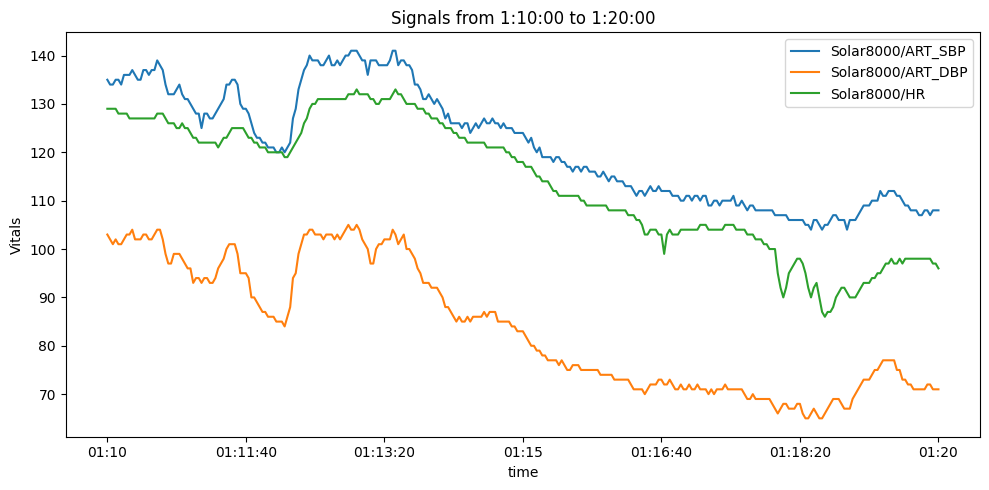

In [24]:
vitals_no_event.loc[time(1,10,00):time(1,20,00), :'Solar8000/HR'].plot(title='Signals from 1:10:00 to 1:20:00',ylabel='Vitals', figsize=(10,5))
plt.legend(loc='best')
plt.tight_layout()

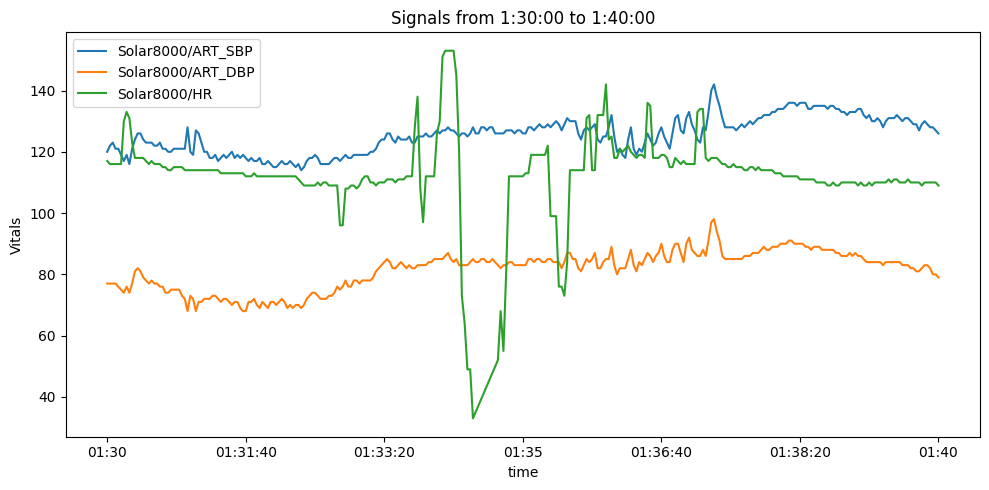

In [25]:
vitals_no_event.loc[time(1,30,00):time(1,40,00), :'Solar8000/HR'].plot(title='Signals from 1:30:00 to 1:40:00',ylabel='Vitals', figsize=(10,5))
plt.tight_layout()

# Discussion And Conclusion

## **Temporal Analysis of Correlation and Signal Features**

Temporal analysis of the heart rate and blood pressure signals provides critical insight into the physiological dynamics of the patient during surgery. By examining correlation patterns within specific time windows, it is possible to infer the presence of normal or abnormal physiological states and potentially align them with surgical events or interventions.

In one such exploratory analysis, as an example, the time interval from **1:00:00 to 2:00:00** was segmented into smaller 10-minute sub-windows to facilitate localized correlation analysis between **heart rate (HR)** and **blood pressure (both systolic and diastolic)**. Notably, in the sub-window spanning **1:10:00 to 1:20:00**, the correlation coefficient between HR and BP was significantly elevated (0.96), suggesting a physiologically expected event; reflecting a stable hemodynamic phase under steady anesthesia or routine surgical manipulation. This correlation was also shown through visual inspection of the overlaid time series plots, where co-trending patterns were clearly observed.

Conversely, the subsequent sub-window from **1:30:00 to 1:40:00** exhibited a marked **reduction in correlation**, with HR and BP deviating from their earlier synchronous behavior(correlation -0.07). Such a decoupling between the two signals is clinically meaningful; it may reflect a transient physiological disturbance, a pharmacological intervention, or a procedural event that disproportionately affected one signal. This anomaly was visually confirmed in the plots, where HR displayed rapid oscillations while BP maintained a relatively steady trend.

Further signal-specific statistical analysis revealed a **significant increase in variance (heart rate variance 309.85)** of the HR signal during the same anomalous interval (1:30:00 to 1:40:00). Also we obsevered a -2.29 skewness which tells us the data was highly left-skewed, meaning there had been a sudden drop in the heart rate. This event in a typically constrained physiological variable like HR can indicate episodes of tachycardia, arrhythmia, or poor signal acquisition due to movement artifacts or probe repositioning. The presence of such isolated variance supports the hypothesis that this time window captures a clinically relevant irregularity.

This temporal-correlation-based approach demonstrates that **signal statistical features and inter-signal dynamics** are effective tools for identifying abnormal events or transitions in physiological states. Such methodologies can serve as a foundation for developing automated detection algorithms for intraoperative anomalies and decision support systems in surgical monitoring.

* Written using chat-gpt for a more professional and scientific tone.
